In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import matplotlib.gridspec as gridspec

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Charter", "Bitstream Charter"],
    "font.style": "normal",
})

### Residuals Comparison

In [3]:
age_test_folder = '../output/age_predictor/performance_tests/'

gyro = pd.read_csv(age_test_folder + 'gyro-multiscale/gyro_kfold_predictions.csv')
baseline = pd.read_csv(age_test_folder + 'baseline-multiscale/kfold_predictions.csv')
unet = pd.read_csv(age_test_folder + 'unet-multiscale/kfold_predictions.csv')
lw_conv = pd.read_csv(age_test_folder + 'lightweight_conv-multiscale/kfold_predictions.csv')
stellar_props = pd.read_csv(age_test_folder + 'stellar_props-multiscale/kfold_predictions.csv')
props_unet = pd.read_csv(age_test_folder + 'props_unet-multiscale/kfold_predictions.csv')
long_curve = pd.read_csv(age_test_folder + 'long_curve-multiscale/kfold_predictions.csv')
baseline_long = pd.read_csv(age_test_folder + 'baseline-long-multiscale/kfold_predictions.csv')
cf_final = pd.read_csv(age_test_folder + 'cf-final-multiscale/kfold_predictions.csv')

scatter_gyro = np.nanstd(gyro['log_residual'])
scatter_baseline = np.nanstd(baseline['log_residual'])
scatter_unet = np.nanstd(unet['log_residual'])
scatter_lw_conv = np.nanstd(lw_conv['log_residual'])
scatter_stellar_props = np.nanstd(stellar_props['log_residual'])
scatter_props_unet = np.nanstd(props_unet['log_residual'])
scatter_long_curve = np.nanstd(long_curve['log_residual'])
scatter_baseline_long = np.nanstd(baseline_long['log_residual'])
scatter_cf_final = np.nanstd(cf_final['log_residual'])

### Make aggregation by star

In [44]:
long_curve_agg = pd.DataFrame(columns=long_curve.columns)
long_curve_agg.drop(columns=['fold'], inplace=True)

for tic in long_curve['TIC_ID'].unique():
    subset = long_curve[long_curve['TIC_ID'] == tic]
    true_age = subset['true_age_myr'].iloc[0]
    bprp0 = subset['bprp0'].iloc[0]
    predicted_age = 10**np.log10(subset['predicted_age_myr']).mean()
    log_residual = np.log10(predicted_age) - np.log10(true_age)
    record = {
        'TIC_ID': tic,
        'true_age_myr': true_age,
        'predicted_age_myr': predicted_age,
        'log_residual': log_residual,
        'bprp0': bprp0
    }
    long_curve_agg = pd.concat([long_curve_agg, pd.DataFrame([record])], ignore_index=True)

/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_40507/3901468151.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  long_curve_agg = pd.concat([long_curve_agg, pd.DataFrame([record])], ignore_index=True)


In [45]:
long_curve_agg

,TIC_ID,true_age_myr,predicted_age_myr,bprp0,log_residual
0,405461319,97.00,131.597147,1.023294,0.132475
1,456945485,775.00,640.708671,0.900964,-0.082641
2,118677684,775.00,134.379376,3.136167,-0.760969
3,118681038,2.49,90.938508,1.554253,1.562548
4,456946694,6.22,67.953790,1.016821,1.038423
...,...,...,...,...,...
2489,35154685,97.00,149.619798,1.062559,0.188217
2490,46678194,97.00,94.457655,2.117883,-0.011535
2491,427546152,97.00,121.266943,1.707976,0.096971
2492,46632137,97.00,162.048217,1.686312,0.222873


## Residuals Histogram

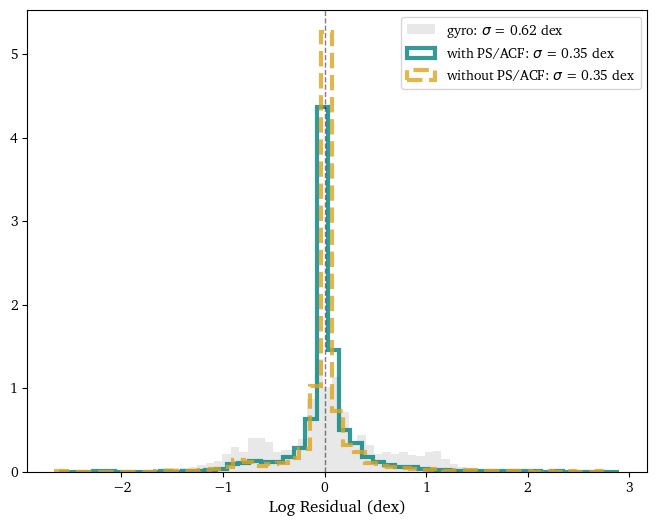

In [21]:
plt.figure(figsize=(8, 6))

plt.hist(gyro['log_residual'], bins=50, alpha=0.5, label=r'gyro: $\sigma$ = {:.2f} dex'.format(scatter_gyro), color='lightgrey',density=True)
# plt.hist(baseline['log_residual'], bins=50, label=r'baseline: $\sigma$ = {:.2f} dex'.format(scatter_baseline), color='magenta',density=True,
#          histtype='step',edgecolor='magenta',linewidth=1, alpha=1)
# plt.hist(unet['log_residual'], bins=50, label=r'UNet: $\sigma$ = {:.2f} dex'.format(scatter_unet), color='cyan',density=True,
#          histtype='step',edgecolor='cyan',linewidth=1, alpha=1)
# plt.hist(lw_conv['log_residual'], bins=50, label=r'Lightweight Conv: $\sigma$ = {:.2f} dex'.format(scatter_lw_conv), color='orange',density=True,
#          histtype='step',edgecolor='orange',linewidth=1, alpha=1)
# plt.hist(stellar_props['log_residual'], bins=50, label=r'Stellar Props: $\sigma$ = {:.2f} dex'.format(scatter_stellar_props), color='green',density=True,
#          histtype='step',edgecolor='green',linewidth=1, alpha=1)
# plt.hist(props_unet['log_residual'], bins=50, label=r'Props + UNet: $\sigma$ = {:.2f} dex'.format(scatter_props_unet), color='blue',density=True,
#          histtype='step',edgecolor='blue',linewidth=1, alpha=1)
plt.hist(long_curve['log_residual'], bins=50, label=r'with PS/ACF: $\sigma$ = {:.2f} dex'.format(scatter_long_curve), color='teal',density=True,
         histtype='step',edgecolor='teal',linewidth=3, alpha=0.8)
plt.hist(baseline_long['log_residual'], bins=50, label=r'without PS/ACF: $\sigma$ = {:.2f} dex'.format(scatter_baseline_long), color='goldenrod',density=True,
         histtype='step',edgecolor='goldenrod',linewidth=3, alpha=0.8,linestyle='--')
# plt.hist(cf_final['log_residual'], bins=50, label=r'CF-final: $\sigma$ = {:.2f} dex'.format(scatter_cf_final), color='brown',density=True,
#          histtype='step',edgecolor='brown',linewidth=1, alpha=1)

plt.xlabel('Log Residual (dex)', fontsize=12)
# plt.ylabel('Density', fontsize=12)
# plt.title('Age Prediction Residuals (Aggregated by TIC_ID)', fontsize=14)
plt.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.legend()
plt.show()

## Plot over Prot/Age/Colour

### Colour

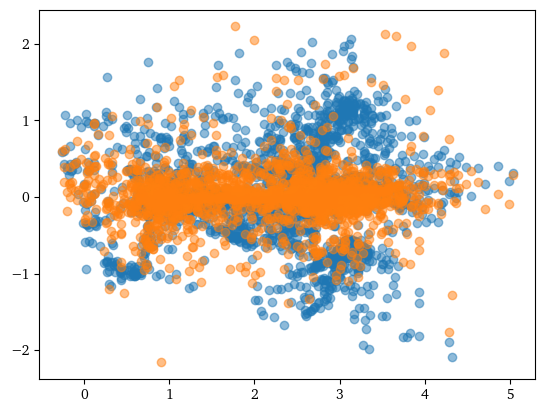

In [46]:
plt.plot((gyro['bprp0']), gyro['log_residual'], 'o', label='gyro', alpha=0.5)
plt.plot(long_curve_agg['bprp0'], long_curve_agg['log_residual'], 'o', label='long curve', alpha=0.5)
plt.show()

### Inferred Age

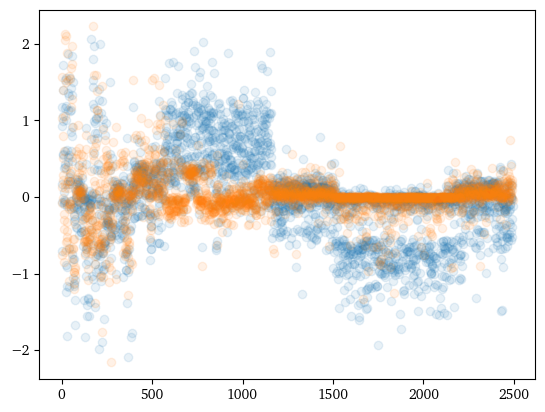

In [48]:
log_pred_age_gyro = np.log10(gyro.sort_values('predicted_age_myr')['predicted_age_myr'])
res_gyro = gyro.sort_values('predicted_age_myr')['log_residual']
log_pred_age_long = np.log10(long_curve_agg.sort_values('predicted_age_myr')['predicted_age_myr'])
res_long = long_curve_agg.sort_values('predicted_age_myr')['log_residual']
plt.plot(res_gyro, 'o', label='gyro', alpha=0.1)
plt.plot(res_long, 'o', label='long curve', alpha=0.1)
plt.show()

## Combined Plot

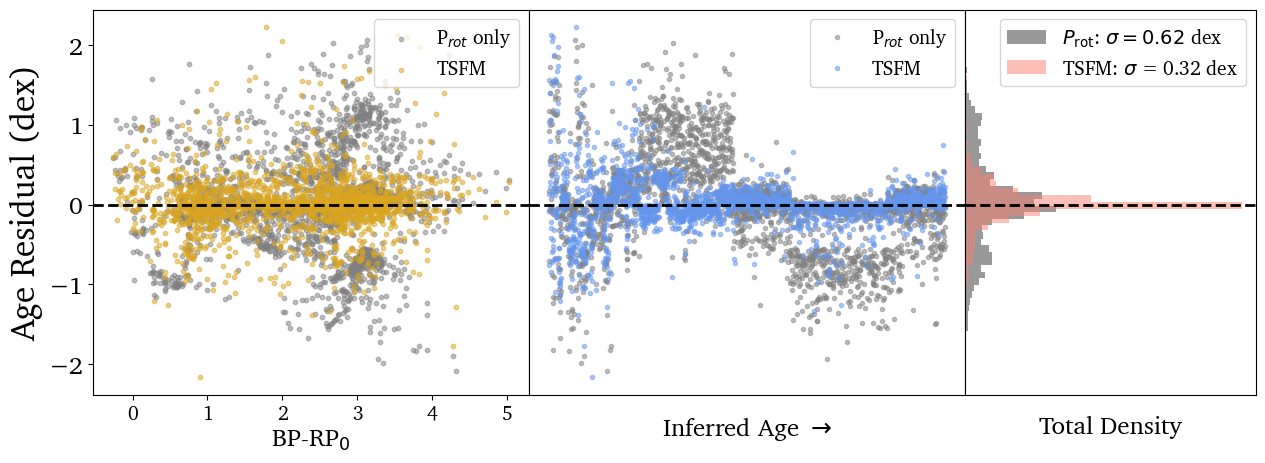

In [156]:
fig = plt.figure(figsize=(15,5))
gs = gridspec.GridSpec(1, 3, width_ratios=[3, 3, 2],wspace=0) 

# Comparison over bprp0
ax0 = fig.add_subplot(gs[0])
ax0.scatter((gyro['bprp0']), gyro['log_residual'], label=r'P$_{rot}$ only', alpha=0.5,s=10,color='grey')
ax0.scatter(long_curve_agg['bprp0'], long_curve_agg['log_residual'],
            label='TSFM',alpha=0.5,s=10,color='goldenrod')
ax0.axhline(0, color='k', linestyle='--', linewidth=2, alpha=1)
ax0.set_ylabel('Age Residual (dex)', fontsize=24)
ax0.tick_params(axis='y', labelsize=18)
ax0.set_xlabel(r'BP-RP$_0$', fontsize=18)
ax0.tick_params(axis='x', labelsize=14)
ax0.legend(fontsize=14,loc='upper right')

# Comparison over inferred age
ax1 = fig.add_subplot(gs[1])
log_pred_age_gyro = np.log10(gyro.sort_values(['predicted_age_myr', 'TIC_ID'])['predicted_age_myr'])
res_gyro = gyro.sort_values(['predicted_age_myr', 'TIC_ID'])['log_residual']
log_pred_age_long = np.log10(long_curve_agg.sort_values(['predicted_age_myr', 'TIC_ID'])['predicted_age_myr'])
res_long = long_curve_agg.sort_values(['predicted_age_myr', 'TIC_ID'])['log_residual']
ax1.plot(res_gyro, 'o', label=r'P$_{rot}$ only', alpha=0.5,color='grey',markersize=3)
ax1.plot(res_long, 'o', label='TSFM', alpha=0.5,color='cornflowerblue',markersize=3)
ax1.axhline(0, color='k', linestyle='--', linewidth=2, alpha=1)
ax1.set_yticks([])
ax1.set_xticks([])
ax1.set_xlabel(r'Inferred Age $\rightarrow$', fontsize=18,labelpad=15)
ax1.legend(fontsize=14)

# Histogram of residuals
ax2 = fig.add_subplot(gs[2])
scatter_gyro = np.nanstd(gyro['log_residual'])
scatter_long_curve = np.nanstd(long_curve_agg['log_residual'])
ax2.hist(gyro['log_residual'], bins=50, alpha=0.8, color='grey',
         density=True,orientation='horizontal',
         label=fr'$P_{{\rm rot}}$: $\sigma = {scatter_gyro:.2f}$ dex',
         linewidth=3)
ax2.hist(long_curve_agg['log_residual'], bins=50,
         color='salmon',density=True,
         linewidth=3, alpha=0.5,orientation='horizontal',label=r'TSFM: $\sigma$ = {:.2f} dex'.format(scatter_long_curve))
ax2.axhline(0, color='k', linestyle='--', linewidth=2, alpha=1)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_xlabel('Total Density', fontsize=18,labelpad=15)
ax2.legend(fontsize=14,loc='upper right')
plt.show()